In [2]:
pip install pandas numpy matplotlib scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install --reinstall matplotlib

Note: you may need to restart the kernel to use updated packages.



Usage:   
  C:\Users\keert\anaconda3\python.exe -m pip install [options] <requirement specifier> [package-index-options] ...
  C:\Users\keert\anaconda3\python.exe -m pip install [options] -r <requirements file> [package-index-options] ...
  C:\Users\keert\anaconda3\python.exe -m pip install [options] [-e] <vcs project url> ...
  C:\Users\keert\anaconda3\python.exe -m pip install [options] [-e] <local project path> ...
  C:\Users\keert\anaconda3\python.exe -m pip install [options] <archive url/path> ...

no such option: --reinstall


In [5]:
pip install --upgrade matplotlib

Note: you may need to restart the kernel to use updated packages.


In [7]:
echo $PATH

$PATH


In [8]:
export path="/path/to/matplotlib/directory:$PATH"

SyntaxError: invalid syntax (1599655012.py, line 1)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [16]:
# Normalize the data
df = pd.read_csv('Stock_prices.csv')

scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

# Create sequences of data for training
sequence_length = 10  # You can adjust this value
X = []
y = []

for i in range(len(df) - sequence_length):
    X.append(df['Close'].values[i:i+sequence_length])
    y.append(df['Close'].values[i+sequence_length])

X = np.array(X)
y = np.array(y)

# Split the data into training and testing sets
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


AttributeError: module 'pandas' has no attribute 'read_csv'

In [15]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
model = Sequential()
model.add(LSTM(50, input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')


NameError: name 'X_train' is not defined

In [8]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
1005/1005 [==============================] - 15s 11ms/step - loss: 0.0061
Epoch 2/10
1005/1005 [==============================] - 11s 11ms/step - loss: 0.0059
Epoch 3/10
1005/1005 [==============================] - 11s 11ms/step - loss: 0.0059
Epoch 4/10
1005/1005 [==============================] - 11s 11ms/step - loss: 0.0058
Epoch 5/10
1005/1005 [==============================] - 11s 11ms/step - loss: 0.0054
Epoch 6/10
1005/1005 [==============================] - 11s 11ms/step - loss: 0.0053
Epoch 7/10
1005/1005 [==============================] - 11s 11ms/step - loss: 0.0052
Epoch 8/10
1005/1005 [==============================] - 11s 11ms/step - loss: 0.0051
Epoch 9/10
1005/1005 [==============================] - 11s 11ms/step - loss: 0.0050
Epoch 10/10
1005/1005 [==============================] - 11s 11ms/step - loss: 0.0048


In [11]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform the predictions to get actual stock prices
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

# Calculate the RMSE (Root Mean Squared Error) to evaluate the model
train_score = np.sqrt(mean_squared_error(y_train, train_predict))
test_score = np.sqrt(mean_squared_error(y_test, test_predict))
print(f"Train RMSE: {train_score}")
print(f"Test RMSE: {test_score}")

251/251 [==============================] - 1s 5ms/step
Train RMSE: 17.0279073259118
Test RMSE: 15.027001808404535


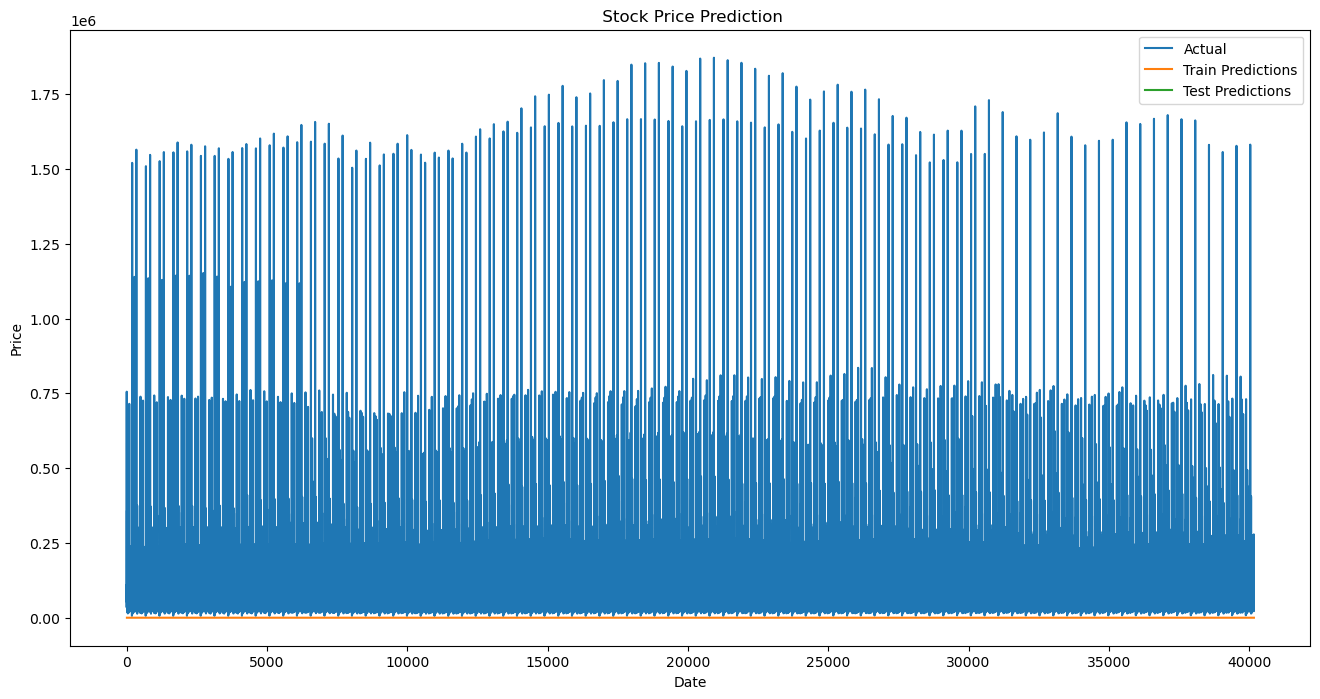

In [12]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Shift predictions for plotting
train_predict_plot = np.empty_like(df['Close'])
train_predict_plot[:sequence_length] = np.nan
train_predict_plot[sequence_length:] = train_predict[0]

test_predict_plot = np.empty_like(df['Close'])
test_predict_plot[:] = np.nan
test_predict_plot[len(train_predict)] = test_predict[0]

# Load the stock data
df = pd.read_csv('Stock_prices.csv')

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Fit the MinMaxScaler object to the Close column of the df DataFrame
scaler.fit(df[['Close']].values)

# Inverse transform the Close column of the df DataFrame using the fitted MinMaxScaler object
inverse_transformed_close = scaler.inverse_transform(df[['Close']].values)


# Plot the actual and predicted prices
plt.figure(figsize=(16, 8))
plt.title(f' Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.plot(scaler.inverse_transform(df[['Close']].values), label='Actual')
plt.plot(train_predict_plot, label='Train Predictions')
plt.plot(test_predict_plot, label='Test Predictions')
plt.legend()
plt.show()

In [17]:
pip install --upgrade pandas

     ---------------------------------------- 11.1/11.1 MB 2.2 MB/s eta 0:00:00
     -------------------------------------- 341.8/341.8 kB 2.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 1.5.3
    Uninstalling pandas-1.5.3:
      Successfully uninstalled pandas-1.5.3
Note: you may need to restart the kernel to use updated packages.


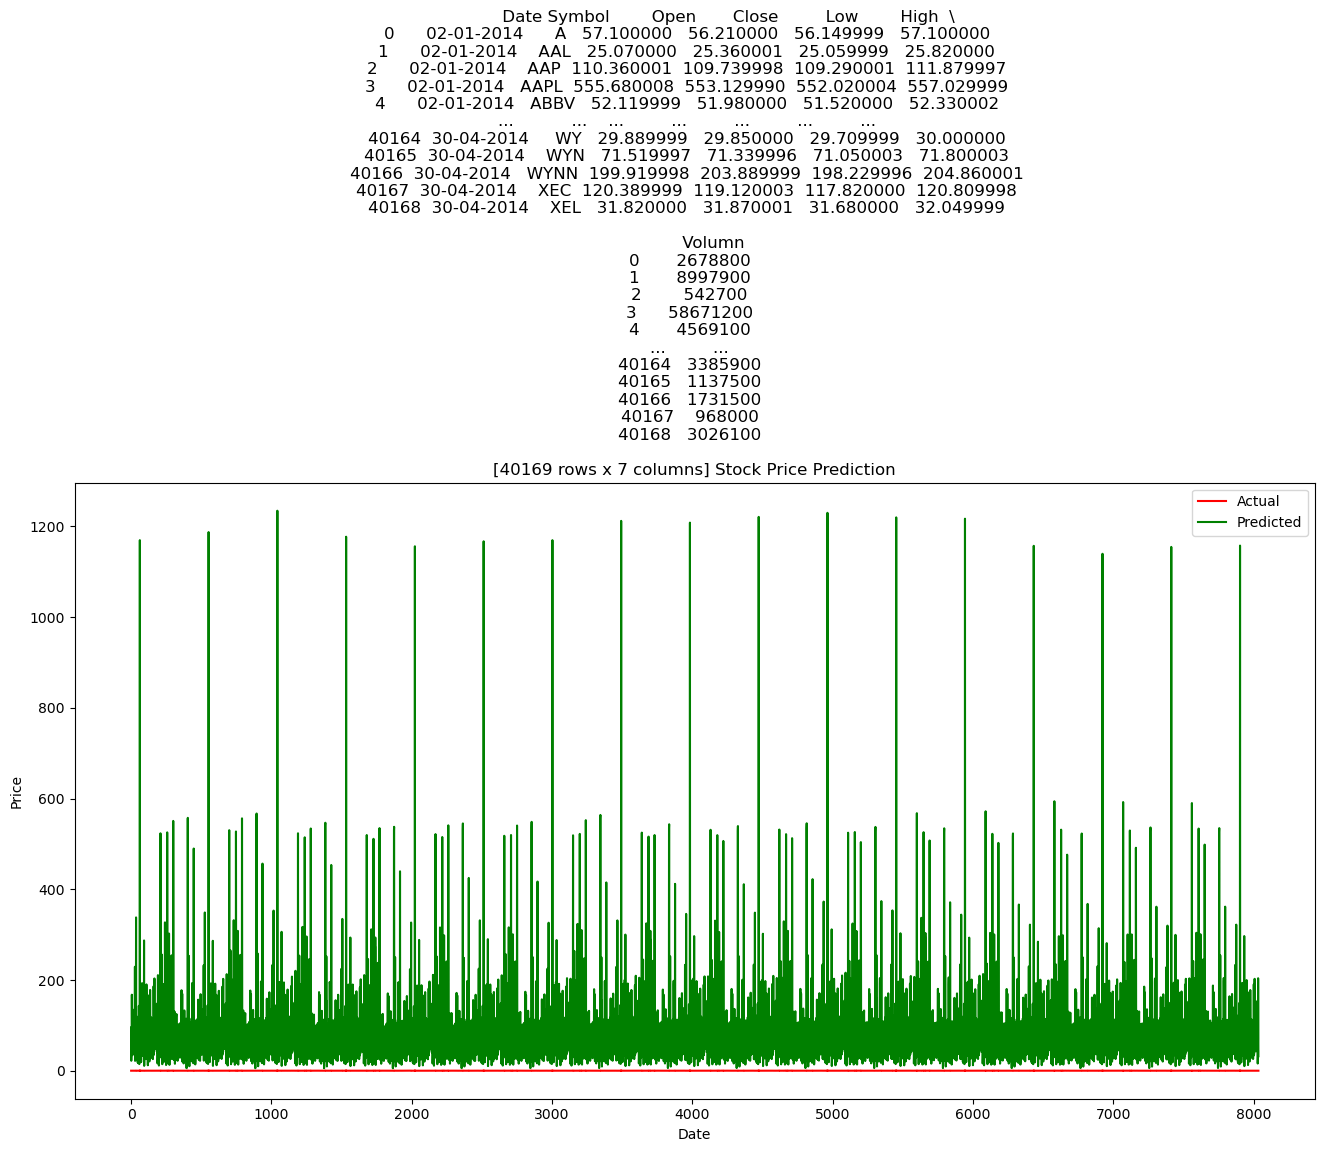

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load the stock data
data = pd.read_csv('Stock_prices.csv')

# Preprocess the data
closing_prices = data['Close'].to_numpy()
closing_prices = closing_prices.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler()
closing_prices = scaler.fit_transform(closing_prices)

# Split the data into train and test sets
train_size = int(len(closing_prices) * 0.8)
test_size = len(closing_prices) - train_size

train_data = closing_prices[:train_size]
test_data = closing_prices[train_size:]

# Create the linear regression model
model = LinearRegression()

# Train the model
model.fit(train_data, train_data)

# Make predictions
predictions = model.predict(test_data)

# Inverse scale the predictions
predictions = scaler.inverse_transform(predictions)

# Plot the predictions
plt.figure(figsize=(16, 8))
plt.title(f'{data} Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.plot(test_data, label='Actual', color='r')
plt.plot(predictions, label='Predicted', color='g')
plt.legend()
plt.show()

In [8]:
df=pd.read_csv('Stock_prices.csv')
df.tail()
df=df.loc[df['Symbol'] == 'CSCO']
print(df.tail())

             Data Symbol       Open      Close        Low       High    Volumn
37840  24-04-2014   CSCO  23.639999  23.330000  23.240000  23.639999  33976700
38330  25-04-2014   CSCO  23.270000  23.000000  22.879999  23.320000  25087300
38820  28-04-2014   CSCO  23.150000  23.020000  22.790001  23.240000  36817100
39310  29-04-2014   CSCO  23.200001  23.160000  23.059999  23.209999  14582400
39800  30-04-2014   CSCO  23.080000  23.110001  22.920000  23.139999  23979300


In [3]:
df=pd.read_csv('Stock_prices.csv')
df.tail()
df=df.loc[df['Symbol'] == 'AAL']
print(df.tail())

             Date Symbol       Open      Close        Low       High    Volumn
37732  24-04-2014    AAL  37.840000  37.259998  35.799999  38.240002  21038700
38222  25-04-2014    AAL  37.000000  36.000000  35.910000  37.110001   9574100
38712  28-04-2014    AAL  36.410000  35.160000  34.340000  36.720001  13149300
39202  29-04-2014    AAL  35.200001  35.509998  34.970001  35.650002   8994200
39692  30-04-2014    AAL  35.680000  35.070000  34.889999  35.880001   6944600


In [5]:
df=pd.read_csv('Stock_prices.csv')
df.tail()
df=df.loc[df['Symbol'] == 'BIIB']
print(df.tail())

             Date Symbol        Open       Close         Low        High  \
37793  24-04-2014   BIIB  307.000000  294.839996  286.480011  308.720001   
38283  25-04-2014   BIIB  293.040009  285.809998  285.579987  296.739990   
38773  28-04-2014   BIIB  289.160004  283.119995  275.390015  292.420013   
39263  29-04-2014   BIIB  285.350006  290.839996  282.000000  294.359985   
39753  30-04-2014   BIIB  285.000000  287.119995  281.320007  291.559998   

        Volumn  
37793  2385300  
38283  1727700  
38773  1802300  
39263  1634500  
39753  1452100  


In [6]:
df=pd.read_csv('Stock_prices.csv')
df.tail()
df=df.loc[df['Symbol'] == 'DOV']
print(df.tail())

             Date Symbol       Open      Close        Low       High   Volumn
37865  24-04-2014    DOV  86.790001  86.190002  85.480003  86.790001  1060500
38355  25-04-2014    DOV  85.720001  84.900002  84.720001  85.989998  1196100
38845  28-04-2014    DOV  85.620003  85.480003  84.220001  85.870003   919500
39335  29-04-2014    DOV  85.690002  85.660004  85.059998  86.089996   513600
39825  30-04-2014    DOV  85.650002  86.400002  85.230003  86.400002   822900


In [7]:
df=pd.read_csv('Stock_prices.csv')
df.tail()
df=df.loc[df['Symbol'] == 'ENDP']
print(df.tail())

             Date Symbol       Open      Close        Low       High   Volumn
37882  24-04-2014   ENDP  61.000000  61.860001  60.189999  62.310001  2644600
38372  25-04-2014   ENDP  62.160000  60.639999  60.400002  62.720001  3370800
38862  28-04-2014   ENDP  61.259998  60.560001  59.689999  61.900002  3076400
39352  29-04-2014   ENDP  60.820000  63.250000  60.570000  63.599998  3607500
39842  30-04-2014   ENDP  63.270000  62.950001  62.110001  65.000000  5206000


In [8]:
df=pd.read_csv('Stock_prices.csv')
df.tail()
df=df.loc[df['Symbol'] == 'FLS']
print(df.tail())

             Date Symbol       Open      Close        Low       High   Volumn
37913  24-04-2014    FLS  77.489998  73.959999  73.010002  77.489998  4158500
38403  25-04-2014    FLS  73.360001  72.870003  72.769997  74.889999  1642300
38893  28-04-2014    FLS  73.110001  72.190002  71.180000  73.680000  1463700
39383  29-04-2014    FLS  72.510002  72.029999  71.470001  72.849998  1182100
39873  30-04-2014    FLS  72.129997  73.050003  71.760002  73.250000  1042100


In [39]:
import math

forecast_col = 'Close'
df.fillna(value=-99999, inplace=True)
forecast_out = int(math.ceil(0.01 * len(df)))
print(forecast_out)
df['label'] = df[forecast_col].shift(-forecast_out)
print(df.head())

402
         Date Symbol        Open       Close         Low        High  \
0  02-01-2014      A   57.100000   56.210000   56.149999   57.100000   
1  02-01-2014    AAL   25.070000   25.360001   25.059999   25.820000   
2  02-01-2014    AAP  110.360001  109.739998  109.290001  111.879997   
3  02-01-2014   AAPL  555.680008  553.129990  552.020004  557.029999   
4  02-01-2014   ABBV   52.119999   51.980000   51.520000   52.330002   

     Volumn       label  
0   2678800   77.750000  
1   8997900   15.590000  
2    542700  114.879997  
3  58671200   88.440002  
4   4569100   36.520000  


In [40]:
""""import pandas as pd

df['Date'] = pd.to_datetime(df['Date'])
df['Date'] = df['Date'].dt.timestamp"""

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Date'] = le.fit_transform(df['Date'])

from sklearn.preprocessing import scale

X = df.drop(['Symbol', 'Date'], axis=1)
X = scale(X)


In [41]:
conda install scikit-learn

Solving environment: ...working... done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.




==> WARNING: A newer version of conda exists. <==
  current version: 23.3.1
  latest version: 23.7.4

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=23.7.4




In [ ]:
conda update -n base -c defaults conda

In [58]:
forecast_col = 'Close'
df.fillna(value=-99999, inplace=True)
forecast_out = int(math.ceil(0.01 * len(df)))
print(forecast_out)
df['label'] = df[forecast_col].shift(-forecast_out)
print(df.head())

402
         Date Symbol        Open       Close         Low        High  \
0  02-01-2014      A   57.100000   56.210000   56.149999   57.100000   
1  02-01-2014    AAL   25.070000   25.360001   25.059999   25.820000   
2  02-01-2014    AAP  110.360001  109.739998  109.290001  111.879997   
3  02-01-2014   AAPL  555.680008  553.129990  552.020004  557.029999   
4  02-01-2014   ABBV   52.119999   51.980000   51.520000   52.330002   

     Volumn       label  
0   2678800   77.750000  
1   8997900   15.590000  
2    542700  114.879997  
3  58671200   88.440002  
4   4569100   36.520000  


In [ ]:
X=np.array(df.drop(['label','symbol','date'], axis=1))
#print(X)
X = preprocessing.scale(X)
#print(X)
X_lately = X[-forecast_out:]
#print(X_lately)
X = X[:-forecast_out]
df.dropna(inplace=True)
y = np.array(df['label'])
X_train, X_test, y_train, y_test = cross_validation.train_test_split(X, y, test_size=0.2)

In [16]:
pip install scikit-learn --upgrade

Note: you may need to restart the kernel to use updated packages.


In [50]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('Stock_prices.csv')

X = np.array(df.drop(['Symbol', 'Date'], axis=1))

df.dropna(subset=['Date'], inplace=True)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)




# Drop the label, symbol, and date columns
X = np.array(df.drop(['Symbol', 'Date'], axis=1))

# Scale the data
X = preprocessing.scale(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\keert\anaconda3\lib\site-packages\IPython\core\interactiveshell.py", line 3460, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\keert\AppData\Local\Temp\ipykernel_2784\2935886876.py", line 13, in <module>
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  File "C:\Users\keert\anaconda3\lib\site-packages\sklearn\utils\_param_validation.py", line 211, in wrapper
    return func(*args, **kwargs)
  File "C:\Users\keert\anaconda3\lib\site-packages\sklearn\model_selection\_split.py", line 2646, in train_test_split
  File "C:\Users\keert\anaconda3\lib\site-packages\sklearn\utils\validation.py", line 453, in indexable
  File "C:\Users\keert\anaconda3\lib\site-packages\sklearn\utils\validation.py", line 407, in check_consistent_length
    uniques = np.unique(lengths)
ValueError: Found input variables with inconsistent numbers of samples: [40169, 40159]

During handling of the above